<a href="https://colab.research.google.com/github/devabhinavraj/Hybrid-Quantum-CNN/blob/main/quantum_cnn_99967a_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [31]:
# Import libraries
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [32]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{\r\n  "username": "abhinavraj19",\r\n  "key": "KGAT_2e5fb77cad1280d25009583ac1853dce"\r\n}'}

In [62]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mkdir: cannot create directory ‘/root/.kaggle’: File exists
cp: cannot stat 'kaggle.json': No such file or directory


In [34]:
!cat ~/.kaggle/kaggle.json

{
  "username": "abhinavraj19",
  "key": "KGAT_2e5fb77cad1280d25009583ac1853dce"
}

In [35]:
!cat ~/.kaggle/kaggle.json

{
  "username": "abhinavraj19",
  "key": "KGAT_2e5fb77cad1280d25009583ac1853dce"
}

In [36]:
{
  "username": "abhinavraj19",
  "key": "KGAT_2d76e4821e97be017cf784092119e7fc"
}

{'username': 'abhinavraj19', 'key': 'KGAT_2d76e4821e97be017cf784092119e7fc'}

In [37]:
!kaggle datasets download -d anaselmasry/breast-cancer-dataset

Dataset URL: https://www.kaggle.com/datasets/anaselmasry/breast-cancer-dataset
License(s): copyright-authors
breast-cancer-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [38]:
import os
print(os.listdir("/content"))

['.config', 'breast-cancer-dataset.zip', 'kaggle (1).json', 'drive', 'kaggle.json', 'BreaKHis_Total_dataset', 'sample_data']


In [39]:
DATASET_PATH = "/content/BreaKHis_Total_dataset"

Creating train, test and validation data

In [40]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [41]:
import os
os.system('unzip -o -q /content/breast-cancer-dataset.zip -d /content/')

DATASET_PATH = "/content/BreaKHis_Total_dataset"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Found 6228 images belonging to 2 classes.
Found 1555 images belonging to 2 classes.


In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Building a model

In [43]:
#model = tf.keras.Sequential([

#    tf.keras.layers.Conv2D(32,(3,3),activation="relu",input_shape=(128,128,3)),
#    tf.keras.layers.MaxPooling2D(),

 #   tf.keras.layers.Conv2D(64,(3,3),activation="relu"),
 #   tf.keras.layers.MaxPooling2D(),

#    tf.keras.layers.Conv2D(128,(3,3),activation="relu"),
 #   tf.keras.layers.MaxPooling2D(),

  #  tf.keras.layers.Flatten(),

   # tf.keras.layers.Dense(128,activation="relu"),
    #tf.keras.layers.Dense(train_data.num_classes,activation="softmax")
#])

Compile

In [44]:
#model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

Train

In [45]:
#history = model.fit(
 #   train_data,
 #   validation_data=val_data,
 #  epochs=3
#)

### Data set size was huge, reducing number of images

In [46]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path

Dataset

In [47]:
DATASET_PATH = "/content/BreaKHis_Total_dataset"

In [48]:
DATASET_PATH = Path(DATASET_PATH)

benign_images = list((DATASET_PATH/"benign").glob("*"))
malignant_images = list((DATASET_PATH/"malignant").glob("*"))

random.seed(42)
print("Benign Images:", len(benign_images))
print("Malignant Images:", len(malignant_images))

Benign Images: 2479
Malignant Images: 5304


In [49]:
benign_sampled = random.sample(benign_images, min(len(benign_images), 2000)) # Sample up to 2000 benign images
malignant_sampled = random.sample(malignant_images, min(len(malignant_images), 2000)) # Sample up to 2000 malignant images

In [50]:
print("Sampled Benign Images:", len(benign_sampled))
print("Sampled Malignant Images:", len(malignant_sampled))

Sampled Benign Images: 2000
Sampled Malignant Images: 2000


In [51]:
files = []
labels = []

for f in benign_sampled:
    files.append(str(f))
    labels.append(0) # 0 for benign

for f in malignant_sampled:
    files.append(str(f))
    labels.append(1) # 1 for malignant

print("Total sampled images:", len(files))

Total sampled images: 4000


In [52]:
from sklearn.model_selection import train_test_split
import numpy as np

# Reconstruct files and labels to ensure consistency
files = []
labels = []

for f in benign_sampled:
    files.append(str(f))
    labels.append(0) # 0 for benign

for f in malignant_sampled:
    files.append(str(f))
    labels.append(1) # 1 for malignant

# Convert to numpy arrays for robust splitting
files_np = np.array(files)
labels_np = np.array(labels)

train_files, test_files, train_labels, test_labels = train_test_split(
    files_np, labels_np, test_size=0.15, random_state=42, stratify=labels_np
)

train_files, val_files, train_labels, val_labels = train_test_split(
    train_files, train_labels, test_size=0.15, random_state=42, stratify=train_labels
)

print(len(train_files), len(val_files), len(test_files))

2890 510 600


In [53]:
IMG_SIZE = (128,128)

def preprocess(path, label):

    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)

    img = tf.image.resize(img, IMG_SIZE)

    img = tf.cast(img, tf.float32)/255.0

    return img, label

In [54]:
def create_dataset(files, labels):

    ds = tf.data.Dataset.from_tensor_slices((files, labels))

    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(32)

    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

In [55]:
train_ds = create_dataset(train_files, train_labels)
val_ds = create_dataset(val_files, val_labels)
test_ds = create_dataset(test_files, test_labels)

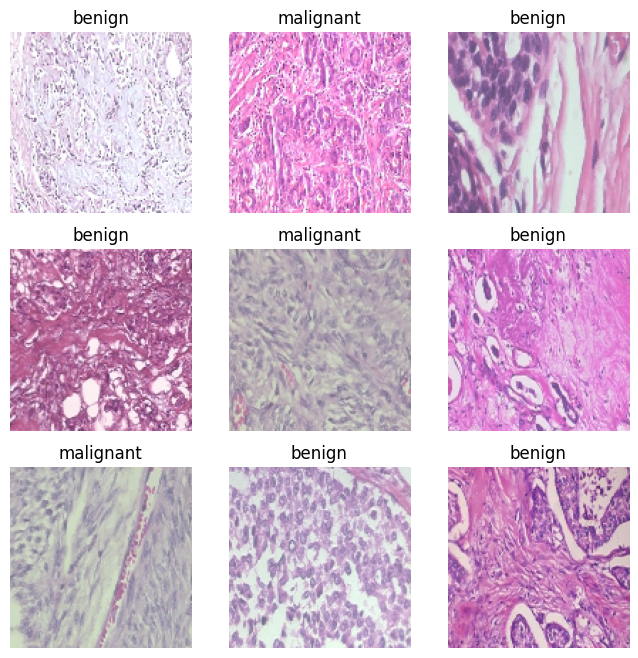

In [56]:
plt.figure(figsize=(8,8))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i])

        plt.title("benign" if labels[i]==1 else "malignant")

        plt.axis("off")

plt.show()

In [57]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32,(3,3),activation="relu",input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation="relu"),

    tf.keras.layers.Dense(1,activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [58]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]
)

In [30]:
history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=5
)
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)

Epoch 1/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.6785 - loss: 0.6192 - val_accuracy: 0.7922 - val_loss: 0.4928
Epoch 2/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - accuracy: 0.7682 - loss: 0.5181 - val_accuracy: 0.8020 - val_loss: 0.4765
Epoch 3/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.7955 - loss: 0.4832 - val_accuracy: 0.8098 - val_loss: 0.4592
Epoch 4/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.8028 - loss: 0.4731 - val_accuracy: 0.8216 - val_loss: 0.4411
Epoch 5/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.8066 - loss: 0.4643 - val_accuracy: 0.8216 - val_loss: 0.4410
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 758ms/step - accuracy: 0.8083 - loss: 0.4592
Test Accuracy: 0.8083333373069763


In [59]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 713ms/step - accuracy: 0.5000 - loss: 0.6936
Test Accuracy: 0.5


# Quantum CNN

In [67]:
# Install PennyLane
!pip install pennylane pennylane-lightning -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pennylane as qml
import numpy as np

############################################
# Convert Dataset
############################################

def tf_to_numpy(dataset):
    images, labels = [], []
    for x, y in dataset:
        images.append(x.numpy())
        labels.append(y.numpy())
    return np.concatenate(images), np.concatenate(labels)

X_train, y_train = tf_to_numpy(train_ds)
X_test, y_test   = tf_to_numpy(test_ds)

X_train = torch.tensor(X_train).permute(0,3,1,2).float()
X_test  = torch.tensor(X_test).permute(0,3,1,2).float()

y_train = torch.tensor(y_train).float()
y_test  = torch.tensor(y_test).float()

trainloader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)
testloader  = DataLoader(TensorDataset(X_test, y_test), batch_size=16)

############################################
# Quantum Device
############################################

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

############################################
# Quantum Circuit WITH POOLING
############################################

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights, pool_params):

    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)
        qml.RZ(inputs[i], wires=i)

    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))

    # Quantum pooling
    qml.CRY(pool_params[0], wires=[0,1])
    qml.CRY(pool_params[1], wires=[1,0])

    qml.CRY(pool_params[2], wires=[2,3])
    qml.CRY(pool_params[3], wires=[3,2])

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

############################################
# Quantum Layer
############################################

class QuantumLayer(nn.Module):
    def __init__(self):
        super().__init__()

        self.weights = nn.Parameter(0.01 * torch.randn(3, n_qubits, 3))
        self.pool_params = nn.Parameter(torch.randn(4))

    def forward(self, x):

        outputs = []

        for i in range(x.shape[0]):

            q_out = quantum_circuit(
                x[i],
                self.weights,
                self.pool_params
            )

            q_out = torch.stack(q_out).float()
            outputs.append(q_out)

        return torch.stack(outputs)

############################################
# Hybrid QCNN
############################################

class HybridQCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((7,7))
        )

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(8*7*7, n_qubits)

        self.quantum = QuantumLayer()

        self.fc2 = nn.Linear(n_qubits, 1)

    def forward(self, x):

        x = self.conv(x)
        x = self.flatten(x)
        x = self.fc1(x)

        x = torch.tanh(x) * np.pi

        x = self.quantum(x)
        x = self.fc2(x)

        return torch.sigmoid(x)

############################################
# Model + Training
############################################

model = HybridQCNN()

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):

    model.train()
    total_loss = 0

    for images, labels in trainloader:

        labels = labels.unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(trainloader):.4f}")

############################################
# Testing
############################################

model.eval()
correct, total = 0, 0

with torch.no_grad():

    for images, labels in testloader:

        labels = labels.unsqueeze(1)

        outputs = model(images)

        predicted = (outputs > 0.5).float()

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

############################################
# 🔥 EXPLAINABILITY PART (NEW)
############################################

def compute_saliency(model, image):
    model.eval()

    image = image.unsqueeze(0)
    image.requires_grad = True

    output = model(image)

    output.backward()

    saliency = image.grad.data.abs().squeeze()

    return saliency


def compute_feature_importance(model, loader):
    model.eval()

    importance = []

    for images, _ in loader:

        images.requires_grad = True

        outputs = model(images)
        loss = outputs.mean()

        model.zero_grad()
        loss.backward()

        grad = images.grad.abs().mean(dim=0)

        importance.append(grad)

    importance = torch.stack(importance).mean(dim=0)

    return importance


############################################
# Run Explainability
############################################

# Example saliency map
sample_img, _ = next(iter(testloader))
saliency = compute_saliency(model, sample_img[0])

print("Saliency map shape:", saliency.shape)

# Feature importance
importance = compute_feature_importance(model, testloader)

print("Feature importance shape:", importance.shape)

Epoch 1, Loss: 0.5569
Epoch 2, Loss: 0.5206
Epoch 3, Loss: 0.4985
Epoch 4, Loss: 0.4773
Epoch 5, Loss: 0.4453
Test Accuracy: 81.33%
Saliency map shape: torch.Size([3, 128, 128])
Feature importance shape: torch.Size([3, 128, 128])


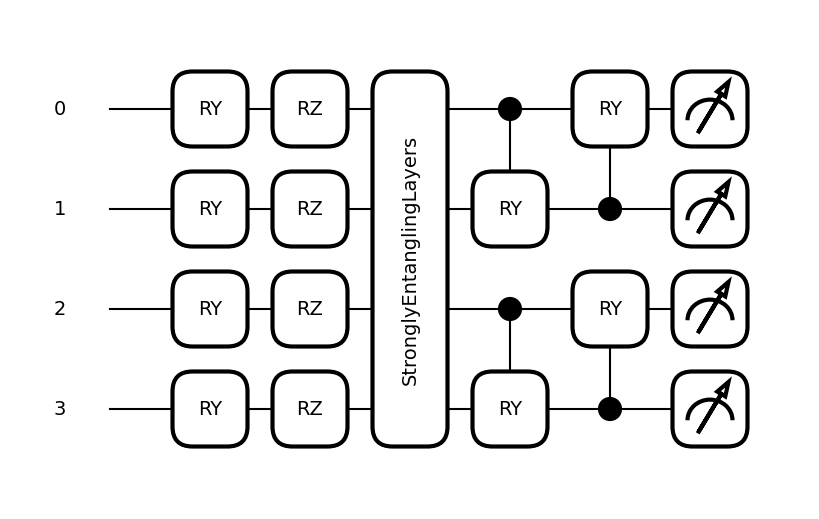

In [68]:
import matplotlib.pyplot as plt
import torch

# Define sample inputs and weights for drawing the circuit
sample_inputs = torch.randn(n_qubits) # n_qubits is 4 from earlier definition
sample_weights = torch.randn(3, n_qubits, 3) # Matches weight_shapes: (3, n_qubits, 3)
sample_pool_params = torch.randn(4) # Add sample pool_params

# Draw with matplotlib
fig, ax = qml.draw_mpl(quantum_circuit)(sample_inputs, sample_weights, sample_pool_params)
plt.show()

# Save the figure
fig.savefig('quantum_circuit.png', dpi=300, bbox_inches='tight')

In [69]:
print(qml.draw(quantum_circuit)(torch.randn(4), torch.randn(3,4,3), torch.randn(4)))

0: ──RY(1.23)───RZ(1.23)──╭StronglyEntanglingLayers(M0)─╭●─────────╭RY(1.79)─┤  <Z>
1: ──RY(2.08)───RZ(2.08)──├StronglyEntanglingLayers(M0)─╰RY(-1.28)─╰●────────┤  <Z>
2: ──RY(-0.60)──RZ(-0.60)─├StronglyEntanglingLayers(M0)─╭●─────────╭RY(1.35)─┤  <Z>
3: ──RY(-0.88)──RZ(-0.88)─╰StronglyEntanglingLayers(M0)─╰RY(-1.58)─╰●────────┤  <Z>

M0 = 
tensor([[[-0.2460,  1.5505, -1.1542],
         [ 0.3741, -0.2210,  0.1088],
         [ 0.9831,  0.7424,  0.2640],
         [-2.0582,  0.3276,  0.0695]],

        [[ 0.4424,  0.3756, -1.3044],
         [ 1.6157,  0.8328, -0.1504],
         [ 0.3535, -0.0880, -0.8224],
         [ 1.0673, -1.1296, -1.1047]],

        [[-0.6213,  0.7149, -0.0922],
         [-0.3730, -1.9853,  0.1079],
         [-0.6152, -0.9995,  0.4264],
         [ 1.7386, -0.5096,  0.6799]]])


# Improvements to the quantum circuit